In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString
from shapely.geometry import box


TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"
MILES_TO_METERS = 1609.344

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)
Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


In [4]:
folder = Path("./maps/raw/historical_districts_by_state/IL")

Illinois = {}

for file in folder.iterdir():
    Illinois[file.name] = gpd.read_file(file).to_crs(TARGET_CRS)

In [3]:
Centerline_Interstates = gpd.read_file("./maps/raw/IL_Interstate_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_USHighways = gpd.read_file("./maps/raw/IL_USHighways_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_StateHighways = gpd.read_file("./maps/raw/IL_StateHighways_Centerlines.geojson").to_crs(TARGET_CRS)

ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)

# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

In [14]:
import geopandas as gpd
import networkx as nx
from shapely.strtree import STRtree
from matplotlib.colors import ListedColormap


def color_polygons_no_adjacent_match(
    gdf,
    palette=None,
):
    """
    Assign colors to polygons so polygons that
    share a boundary edge never have the same color.

    Returns
    -------
    GeoDataFrame
        Copy of the input with:
        - color_id
        - fill_color
    """

    output = gdf.copy()

    # Default pastel palette
    if palette is None:
        palette = [
            "#F4A6A6",  # pastel red
            "#A8D8A8",  # pastel green
            "#A9C7F5",  # pastel blue
            "#F6D58A",  # pastel yellow
            "#C9A7EB",  # pastel purple
            "#F3B5D2",  # pastel pink
            "#A8DAD8",  # pastel teal
            "#F2C6A0",  # pastel orange
        ]

    geometries = (
        output.geometry
        .to_list()
    )

    # Spatial index
    tree = STRtree(
        geometries
    )

    # Polygon adjacency graph
    graph = nx.Graph()

    graph.add_nodes_from(
        output.index
    )

    # Find polygons sharing an edge
    for position, geometry in enumerate(
        geometries
    ):

        if (
            geometry is None
            or geometry.is_empty
        ):
            continue

        candidate_positions = (
            tree.query(
                geometry
            )
        )

        for other_position in (
            candidate_positions
        ):

            if (
                other_position
                <= position
            ):
                continue

            other_geometry = (
                geometries[
                    other_position
                ]
            )

            # Shared boundary geometry
            shared_boundary = (
                geometry.boundary
                .intersection(
                    other_geometry.boundary
                )
            )

            # Only count shared edges.
            # Point-only contact is ignored.
            if (
                shared_boundary.length
                > 0
            ):

                graph.add_edge(
                    output.index[
                        position
                    ],
                    output.index[
                        other_position
                    ],
                )

    # Greedy graph coloring
    color_ids = nx.coloring.greedy_color(
        graph,
        strategy="largest_first",
    )

    # Store color IDs
    output["color_id"] = (
        output.index
        .map(
            color_ids
        )
        .fillna(0)
        .astype(int)
    )

    # Convert IDs into pastel colors
    output["fill_color"] = (
        output["color_id"]
        .apply(
            lambda color_id:
                palette[
                    color_id
                    % len(palette)
                ]
        )
    )

    return output

In [15]:
colored_places = (
    color_polygons_no_adjacent_match(
        ILPlaces2022WithChicagoCommunity_AndCensus
    )
)

In [18]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

In [23]:
# Census Codes

census_codes = {
    "GEO_ID": "GEOID",
    "B02001_001E": "Race",
    "B03002_003E": "White alone, non-Hispanic",
    "B03002_004E": "Black alone, non-Hispanic",
    "B03002_012E": "Hispanic or Latino",
    "B03002_005E": "American Indian and Alaska Native Alone, non-Hispanic",
    "B03002_006E": "Asian Alone, non-Hispanic",
    "B03002_007E": "Native Hawaiian and Other Pacific Islander Alone, non-Hispanic",
    "B15003_020E": "Some college, 1 or more years, no degree", # not in ACS 2010
    "B15003_021E": "Associate's degree",
    "B15003_022E": "Bachelor's degree",
    "B15003_023E": "Master's degree",
    "B15003_024E": "Professional school degree",
    "B15003_025E": "Doctorate degree",
    "B19013_001E": "Median Household Income",
    "B17001_002E": "Income in the past 12 months below poverty level",
    "B25064_001E": "Median Gross Rent",
    "B05001_002E": "Native, Total Population",
    "B05001_004E": "Foreign born, Naturalized U.S. Citizen",
    "B25034_001E": "Total Structures",
    "B25034_002E": "Built 2020s",
    "B25034_003E": "Built 2010s",
    "B25034_004E": "Built 2000s",
    "B25034_005E": "Built 1990s",
    "B25034_006E": "Built 1980s",
    "B25034_007E": "Built 1970s",
    "B25034_008E": "Built 1960s",
    "B25034_009E": "Built 1950s",
    "B25034_010E": "Built 1940s",
    "B25034_011E": "Built Before 1940",
    "B27001_002E": "Male, Health insurance Coverage",
    "B27001_018E": "Female, Health insurance Coverage",
    "B25003_001E": "Occupied Housing Units",
    "B25003_003E": "Renter occupied",
    "B25003_002E": "Owner occupied",
    "B08303_002E": "Travel Time, less than 5 minutes",
    "B08303_003E": "Travel Time, 5-9 minutes",
    "B08303_004E": "Travel Time, 10-14 minutes",
    "B08303_005E": "Travel Time, 15-19 minutes",
    "B08303_006E": "Travel Time, 20-24 minutes",
    "B08303_007E": "Travel Time, 25-29 minutes",
    "B08303_008E": "Travel Time, 30-34 minutes",
    "B08303_009E": "Travel Time, 35-39 minutes",
    "B08303_010E": "Travel Time, 40-44 minutes",
    "B08303_011E": "Travel Time, 45-59 minutes",
    "B08303_012E": "Travel Time, 60-89 minutes",
    "B08303_013E": "Travel Time, 90 minutes or more",
    "B08301_003E": "Car, truck, or van, Drove Alone",
    "B08301_004E": "Car, truck, or van, Carpool",
    "B08301_011E": "Public transportation, Bus",
    "B08301_012E": "Public transportation, Light Rail",
    "B08301_013E": "Public transportation, Hard Rail",
    "B23025_002E": "Labor force",
    "B23025_005E": "Unemployed persons",
    "B23025_007E": "Not in labor force",
    "B16001_001E": "Language at home, Total",
    "B16001_002E": "Language at home, only English",
    "B16001_003E": "Language at home, Spanish",
    "B21001_002E": "Veteran",
    "B11005_001E": "Households",
    "B11005_002E": "Households with one or more people under 18 years",
    "B01001_003E": "Male, Under 5",
    "B01001_004E": "Male, 5 to 9 years",
    "B01001_005E": "Male, 10 to 14 years",
    "B01001_006E": "Male, 15 to 17 years",
    "B01001_007E": "Male, 18 to 19 years",
    "B01001_008E": "Male, 20 years",
    "B01001_009E": "Male, 21 years",
    "B01001_010E": "Male, 22 to 24 years",
    "B01001_011E": "Male, 25 to 29 years",
    "B01001_012E": "Male, 30 to 34 years",
    "B01001_013E": "Male, 35 to 39 years",
    "B01001_014E": "Male, 40 to 44 years",
    "B01001_015E": "Male, 45 to 49 years",
    "B01001_016E": "Male, 50 to 54 years",
    "B01001_017E": "Male, 55 to 59 years",
    "B01001_018E": "Male, 60 and 61 years",
    "B01001_019E": "Male, 62 to 64 years",
    "B01001_020E": "Male, 65 and 66 years",
    "B01001_021E": "Male, 67 to 69 years",
    "B01001_022E": "Male, 70 to 74 years",
    "B01001_023E": "Male, 75 to 79 years",
    "B01001_024E": "Male, 80 to 84 years",
    "B01001_025E": "Male, 85 years and over",
    "B01001_027E": "Female, Under 5",
    "B01001_028E": "Female, 5 to 9 years",
    "B01001_029E": "Female, 10 to 14 years",
    "B01001_030E": "Female, 15 to 17 years",
    "B01001_031E": "Female, 18 to 19 years",
    "B01001_032E": "Female, 20 years",
    "B01001_033E": "Female, 21 years",
    "B01001_034E": "Female, 22 to 24 years",
    "B01001_035E": "Female, 25 to 29 years",
    "B01001_036E": "Female, 30 to 34 years",
    "B01001_037E": "Female, 35 to 39 years",
    "B01001_038E": "Female, 40 to 44 years",
    "B01001_039E": "Female, 45 to 49 years",
    "B01001_040E": "Female, 50 to 54 years",
    "B01001_041E": "Female, 55 to 59 years",
    "B01001_042E": "Female, 60 and 61 years",
    "B01001_043E": "Female, 62 to 64 years",
    "B01001_044E": "Female, 65 and 66 years",
    "B01001_045E": "Female, 67 to 69 years",
    "B01001_046E": "Female, 70 to 74 years",
    "B01001_047E": "Female, 75 to 79 years",
    "B01001_048E": "Female, 80 to 84 years",
    "B01001_049E": "Female, 85 years and over",
}

CODES = {
    value: key
    for key, value in census_codes.items()
}


In [63]:
district = Illinois['IL_CD_2021_30.geojson'][(
    (Illinois['IL_CD_2021_30.geojson']['DISTRICT'] == '3')
)]

colored_places_in_district = gpd.sjoin(
    colored_places,
    district,
    how="inner",
    predicate="intersects"
)

In [67]:

plt.rcParams.update({
    "font.family": "Overpass",
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


In [69]:
from matplotlib import font_manager
import matplotlib.pyplot as plt
from pathlib import Path


# Folder containing the downloaded Overpass .ttf files
font_folder = Path(
    r"C:\Users\Wayne\Downloads\Overpass"
)


# Register every Overpass TTF file
for font_file in font_folder.rglob("*.ttf"):

    font_manager.fontManager.addfont(
        str(font_file)
    )


# Check the exact font names Matplotlib sees
overpass_fonts = [
    font.name
    for font in (
        font_manager.fontManager.ttflist
    )
    if "Overpass" in font.name
]

print(
    sorted(
        set(overpass_fonts)
    )
)

['Overpass']


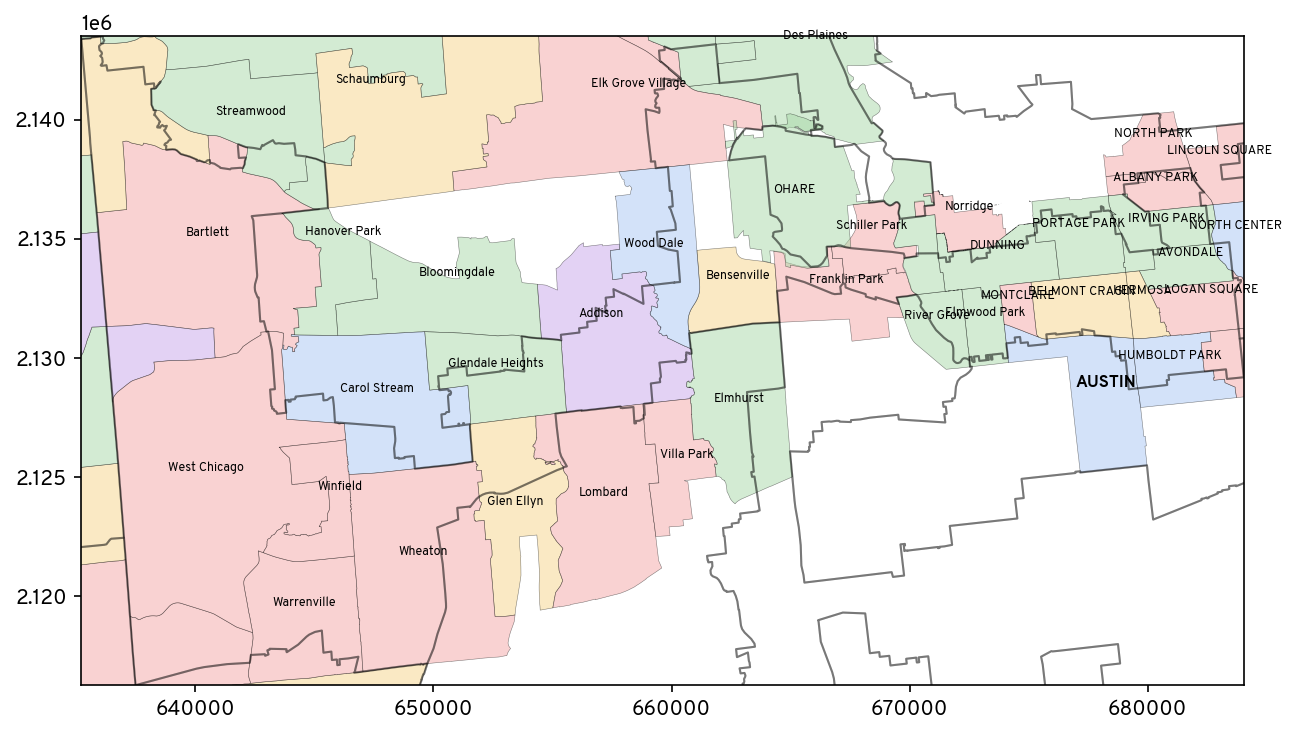

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))

Illinois['IL_CD_2021_30.geojson'].plot(
    ax=ax,
    edgecolor="#00000050",
    facecolor= "#ffffff00",
    zorder=4,
    linewidth=1,
)

colored_places_in_district.plot(
    ax=ax,
    edgecolor='black',
     color=colored_places[
        "fill_color"
    ],
    linewidth=0.25,
    label="IL-8",
    zorder=1,
    alpha=0.5
)



for _, row in colored_places_in_district[
    (colored_places_in_district[CODES['Race']] > 10**5)
].iterrows():

    rep_point = row['geometry'].representative_point()
    ax.annotate(
        text=row["PLACE_NAME"],
        xy=(rep_point.x, rep_point.y),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )

for _, row in colored_places_in_district[
    (colored_places_in_district[CODES['Race']] < 10**5)
].iterrows():

    rep_point = row['geometry'].representative_point()
    ax.annotate(
        text=row["PLACE_NAME"],
        xy=(rep_point.x, rep_point.y),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=6,
    )


ZoomToTheExtentOf(ax, district)

plt.show()